# Module 11, Recitation 1: Exploring LLMs, Tokenization, Attention, Decoding, and Prompting

In this recitation, we explore how Large Language Models (LLMs) process, understand, and generate text.  
We build intuition from the ground up, starting with **tokenization** and ending with **prompting strategies** on a real open-source model (Mistral-7B-Instruct).

The main topics:

### 1. **Tokenization**
How models break text into subword units, map them to integer IDs, and reconstruct text.

### 2. **Embeddings**
How token IDs are transformed into high-dimensional meaning vectors.

### 3. **Similarity & Visualization**
Using cosine similarity and PCA to examine relationships between words.

### 4. **Attention Mechanism**
Intuitive explanation of queries, keys, values, and how attention mixes information across tokens.

### 5. **Attention Heatmaps**
Visualizing which words attend to which, and how this influences representation building.

### 6. **Decoding Strategies**
Comparing greedy decoding, temperature sampling, top-k, and top-p — and how each affects the style and creativity of generated text.

### 7. **Prompting**
Using an actual open model (Mistral-7B-Instruct) to demonstrate:
- zero-shot and few-shot learning  
- chain-of-thought reasoning  
- summarization  
- role prompting  
- good vs bad prompt design  

By the end of the recitation, you will understand not only **how LLMs generate text**,  
but also **how to steer their behavior** through effective prompt design.



## 1. Setup

We'll use only standard Python and a few common scientific libraries:
- `numpy` for simple math
- `random` for sampling
- `matplotlib` for visualizations


In [ ]:

import numpy as np
import random
import math
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
random.seed(42)
np.random.seed(42)


## How are words represented in an LLM?

Before a transformer can process text, it must turn words into vectors that it can operate on.
Here is the process, step by step.

---

### 1. Tokenization → Converting text to IDs

Example sentence:

"The cat sat"


The tokenizer converts each piece of text into an integer ID:

| Token | ID   |
|-------|------|
| the   | 262  |
| cat   | 9246 |
| sat   | 3797 |

Inside the model, "cat" is literally just the number 9246.
But numbers like 262 or 9246 do not carry meaning by themselves.




### Tokenizer

**Τokenization** breaks text into units (tokens) that a model can handle:
- Some tokens are **whole words** (e.g., `"cat"`, `"the"`)
- Some are **subwords** (e.g., `"un"`, `"break"`, `"able"`, `"##york"`)
- Unknown tokens may be mapped to a special `[UNK]` token

Let’s see how a **real LLM tokenizer** behaves on similar examples, using
Hugging Face’s `AutoTokenizer`. This is close to what models like GPT-2 or
LLaMA do internally:

- Break text into subword units
- Map each token to an integer ID
- Be consistent so that the model can map back (decode) to text


In [ ]:
from transformers import AutoTokenizer

# You can swap "gpt2" with another model's tokenizer if you like.
# For a LLaMA-style tokenizer, you'd use a LLaMA checkpoint instead.
tokenizer = AutoTokenizer.from_pretrained("gpt2")

examples = [
    "cat",
    "the",
    "unbreakable",
    "newyork",
    "New York",
    "xylophonic",
    "The cat sat on the mat because it was tired.",
]

for text in examples:
    encoded = tokenizer(text, add_special_tokens=False)
    ids = encoded["input_ids"]
    tokens = tokenizer.convert_ids_to_tokens(ids)
    decoded = tokenizer.decode(ids)

    print(f"\n=== '{text}' ===")
    print("Tokens: ", tokens)
    print("Token IDs:", ids)
    print("Decoded: ", repr(decoded))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]


=== 'cat' ===
Tokens:  ['cat']
Token IDs: [9246]
Decoded:  'cat'

=== 'the' ===
Tokens:  ['the']
Token IDs: [1169]
Decoded:  'the'

=== 'unbreakable' ===
Tokens:  ['un', 'break', 'able']
Token IDs: [403, 9032, 540]
Decoded:  'unbreakable'

=== 'newyork' ===
Tokens:  ['new', 'y', 'ork']
Token IDs: [3605, 88, 967]
Decoded:  'newyork'

=== 'New York' ===
Tokens:  ['New', 'ĠYork']
Token IDs: [3791, 1971]
Decoded:  'New York'

=== 'xylophonic' ===
Tokens:  ['x', 'yl', 'oph', 'onic']
Token IDs: [87, 2645, 2522, 9229]
Decoded:  'xylophonic'

=== 'The cat sat on the mat because it was tired.' ===
Tokens:  ['The', 'Ġcat', 'Ġsat', 'Ġon', 'Ġthe', 'Ġmat', 'Ġbecause', 'Ġit', 'Ġwas', 'Ġtired', '.']
Token IDs: [464, 3797, 3332, 319, 262, 2603, 780, 340, 373, 10032, 13]
Decoded:  'The cat sat on the mat because it was tired.'



### Things to notice

- Some tokens like `"cat"` and `"the"` are mapped directly to single tokens.  
- `"unbreakable"` will be split into subwords (e.g., `"un"`, `"break"`, `"able"`) if they exist in the vocabulary.  
- Words not in the vocabulary will be split (like `"xylophonic"`).


---

### 2. Lookup in the Embedding Matrix

The model has a large learned lookup table called the **embedding matrix**.

- One row per token in the vocabulary  
- Each row is a vector (for example, 768 values)  
- These vectors capture meaning and grammatical relationships  

Example (values are conceptual):

| Token | ID   | Embedding Vector             |
|-------|------|-------------------------------|
| the   | 262  | [0.12, -0.44, 0.09, ...]      |
| cat   | 9246 | [0.81, 0.22, -0.55, ...]      |
| sat   | 3797 | [-0.31, 0.77, 0.03, ...]      |

The model simply performs a lookup:

embeddings[0] = embedding_matrix[262] # "the"\
embeddings[1] = embedding_matrix[9246] # "cat"\
embeddings[2] = embedding_matrix[3797] # "sat"


This produces a sequence of vectors — the **input embeddings**.

---

### 3. Adding Positional Encodings

Embeddings tell the model what each word is, but not where it appears.

Transformers add a positional vector to each embedding to encode order:

final_embedding = token_embedding + positional_embedding


This allows the model to distinguish:

"cat sat"


from

"sat cat"


even though they contain the same tokens.

---

### 4. Feeding Embeddings Into Attention Layers

After token embeddings and positional encodings are combined, the resulting vectors are fed into the first transformer layer.

From there, the model computes queries, keys, and values and begins the self-attention process.

All higher-level reasoning begins from these initial input embeddings.

---

### Simple Analogy

- The tokenizer gives the model a numeric index for each word.  
- The embedding matrix is a dictionary of meanings.  
- Looking up an ID retrieves the word's "meaning vector."  
- The transformer uses these meaning vectors to understand and generate text.

---


In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch

# Use a tiny model to keep it fast and lightweight
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModel.from_pretrained("distilbert-base-uncased")

def get_embedding(token):
    """Return the embedding vector for a single token string."""
    token_id = tokenizer.convert_tokens_to_ids(token)
    embedding_matrix = model.get_input_embeddings()
    return embedding_matrix.weight[token_id].detach()

# Let's examine embeddings for simple tokens
tokens = ["cat", "mat", "the", "tired"]

for tok in tokens:
    emb = get_embedding(tok)
    print(f"Token: {tok:>5} | Embedding shape: {tuple(emb.shape)}")
    print(f"First 10 numbers: {emb[:10].numpy()}\n")


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Token:   cat | Embedding shape: (768,)
First 10 numbers: [-0.009 -0.079 -0.003 -0.068 -0.037 -0.001 -0.007  0.021 -0.034  0.006]

Token:   mat | Embedding shape: (768,)
First 10 numbers: [-0.05  -0.027 -0.011 -0.056 -0.049 -0.088  0.017 -0.076  0.009 -0.054]

Token:   the | Embedding shape: (768,)
First 10 numbers: [-0.046 -0.009  0.002 -0.    -0.025 -0.001 -0.003  0.003  0.004  0.011]

Token: tired | Embedding shape: (768,)
First 10 numbers: [-0.046 -0.005 -0.004  0.007 -0.01  -0.026 -0.089 -0.004 -0.088 -0.049]



We are how going to explore how embeddings encode relationships using cosine similarity.

In [ ]:
import torch.nn.functional as F

def cosine(a, b):
    return F.cosine_similarity(a.unsqueeze(0), b.unsqueeze(0)).item()

pairs = [
    ("cat", "mat"),
    ("cat", "dog"),
    ("cat", "tired"),
    ("the", "mat"),
]

print("Cosine Similarities Between Token Embeddings:\n")
for w1, w2 in pairs:
    v1 = get_embedding(w1)
    v2 = get_embedding(w2)
    print(f"{w1:>5} vs {w2:>5}: {cosine(v1, v2):.3f}")


Cosine Similarities Between Token Embeddings:

  cat vs   mat: 0.415
  cat vs   dog: 0.548
  cat vs tired: 0.355
  the vs   mat: 0.246


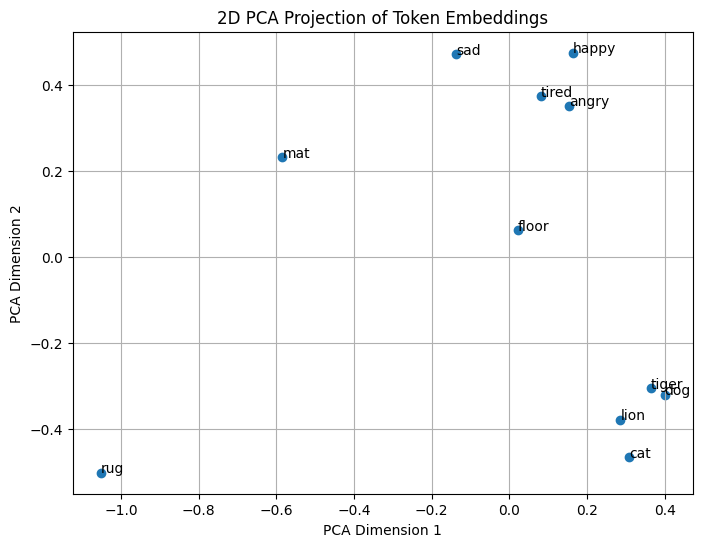

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Load small model for speed
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModel.from_pretrained("distilbert-base-uncased")

# Words to visualize
words = [
    "cat", "dog", "lion", "tiger",
    "mat", "rug", "floor",
    "happy", "sad", "tired", "angry"
]

# Get embeddings
embedding_matrix = model.get_input_embeddings()

vectors = []
valid_words = []
for w in words:
    tok_id = tokenizer.convert_tokens_to_ids(w)
    if tok_id != tokenizer.unk_token_id:   # Skip [UNK] tokens
        vectors.append(embedding_matrix.weight[tok_id].detach().numpy())
        valid_words.append(w)

# PCA to 2D
pca = PCA(n_components=2)
points = pca.fit_transform(vectors)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(points[:, 0], points[:, 1])

for i, word in enumerate(valid_words):
    plt.annotate(word, (points[i, 0], points[i, 1]))

plt.title("2D PCA Projection of Token Embeddings")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.grid(True)
plt.show()


## Encoder Models (BERT) vs. Decoder Models (GPT, Llama, Mistral)

Transformers come in several architectural variants, all built from the same
core components (tokenization → embeddings → attention).

### How These Models Are Trained

All transformer language models learn by **predicting tokens**:

- Decoder-only models (GPT, Llama, Mistral) are trained to predict the **next** token (left → right).
- Encoder-only models (BERT, DistilBERT) are trained with **masked language modeling**, where some tokens are hidden and the model must predict them.

Even though BERT is not autoregressive, it is still trained as a *token prediction* model.  
The difference is what happens **after** training:

### What parts of the model are kept?

- **BERT keeps only the encoder.**  
  The encoder produces contextual embeddings that are great for classification,
  but it cannot generate text because it has no decoder stack.

- **GPT, Llama, and Mistral keep only the decoder.**  
  These models generate text by predicting one token at a time using causal attention.



## How Self-Attention Works (Intuitive Explanation)

Once the model has input embeddings for each token in a sentence, the next step is
to let each token **look at** every other token and decide how important they are.

This mechanism is called **self-attention**.

---

### 1. Each token creates three vectors: Query, Key, and Value

For every token embedding, the model applies three learned linear transformations:

- **Query (Q):** "What am I looking for?"
- **Key (K):** "What information do I contain?"
- **Value (V):** "What information should be passed forward?"

You can think of it like each word turning into:

- Query: what I want to pay attention to
- Key: what I offer to others
- Value: the content I contribute

#### Are Q, K, and V all learned?

Yes. All three of them (Query (Q), Key (K), and Value (V)) come from learned
linear transformations of the input embeddings.

For each token embedding `x`, the model computes:

Q = x · W_Q\
K = x · W_K\
V = x · W_V


where `W_Q`, `W_K`, and `W_V` are different learned weight matrices.

- **Query (Q)**: represents what the token is looking for  
- **Key (K)**: represents what information the token contains  
- **Value (V)**: represents the information the token will pass forward

All three matrices (`W_Q`, `W_K`, `W_V`) are learned during training through
backpropagation. They are updated just like any other neural network weights.

So the Value vectors are not raw embeddings. They are transformed versions of the
token embeddings that contain the information the model uses to build the next
representation of each token.


---

### 2. A token decides how much to attend to each other token

For a given token, the model computes:

attention_score = dot(Query_of_current_token, Key_of_other_token)


If the dot product is high, the current token finds the other token *relevant*.

---

### 3. Softmax turns scores into attention weights

All attention scores from a token are passed through **softmax**, producing weights that:

- are all positive  
- add up to 1  
- represent how much the token attends to each other token  

Example:


[0.01, 0.70, 0.25, 0.04]


means the current token attends mostly to token 2.

---

### 4. Values Are Combined According to Attention Weights

Each row of the attention matrix represents **how much a particular token attends to every other token**.

- A row corresponds to a *query token* (the token doing the looking).
- Each number in that row is the *attention weight* assigned to another token.

For example, if Row 2 of the attention matrix is:

[0.05, 0.70, 0.10, 0.15]


this means:
- Token 2 pays **70% attention** to token 1  
- **15% attention** to token 3  
- Almost **no attention** to token 0  

These weights tell the model **how much information it should pull from each other token**.

Next, the model multiplies this row by the **Value (V) vectors**.

Why?

- **K** says what information each token *offers*  
- **Q** says what information each token *wants*  
- **V** contains the *actual information that gets passed forward*

The weighted sum:

new_representation_of_token_i =
attn[i,0] * V[0] +
attn[i,1] * V[1] +
attn[i,2] * V[2] +
attn[i,3] * V[3]


creates a new vector for token *i* that mixes information from the whole sequence.

This is how each token “updates its understanding” based on the context.

---

### 5. The Attention Matrix

The full attention matrix shows **how all tokens interact with each other**.

- **Rows = Queries** → “Which tokens am I paying attention to?”
- **Columns = Keys** → “Which tokens am I attending to?”

The attention matrix is essentially a map of *information flow*:

- Larger values mean “I care about this token; its information should influence me.”
- Smaller values mean “This token is not relevant right now.”

When we multiply this matrix by **V**, the information is actually passed along to the next layer.

In other words:

- The **attention weights** describe *who listens to whom*.  
- The **Value vectors** contain the *information being transmitted*.  
- The product `Attention × V` creates the updated token representations used in the next part of the model.

This is why the attention matrix is so important:  
it tells us exactly **which words influence each other** and **how strongly**.



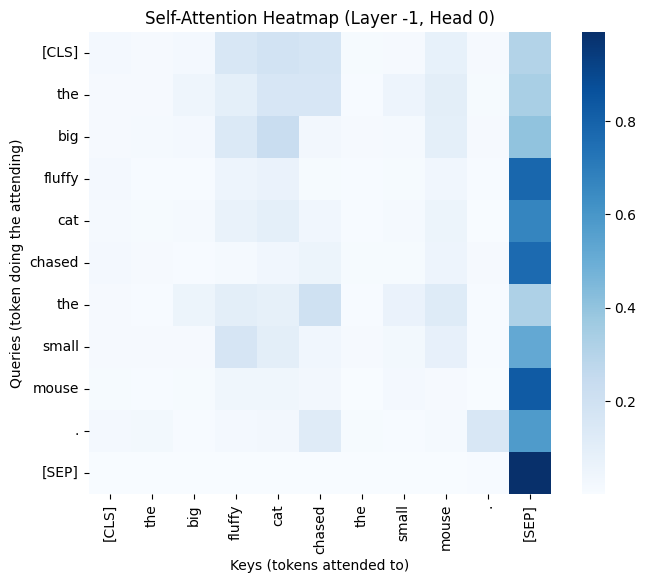

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM

sentence = "The big fluffy cat chased the small mouse."

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, output_attentions=True)
model.eval()

inputs = tokenizer(sentence, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

attentions = outputs.attentions

layer = 2
head = 0
attn = attentions[layer][0, head].numpy()

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

plt.figure(figsize=(8, 6))
sns.heatmap(attn, cmap="Blues", xticklabels=tokens, yticklabels=tokens,
            square=True, annot=False, cbar=True)
plt.title("Self-Attention Heatmap (Layer 2, Head 0)")
plt.xlabel("Keys (tokens attended to)")
plt.ylabel("Queries (token doing the attending)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()


## Decoding Strategies: How a Language Model Chooses the Next Token

A language model produces a probability distribution over the next token.
Decoding determines **how we pick** that next token.

Different decoding methods give very different behaviors.

### 1. Greedy Decoding
Always pick the most likely next token.

- deterministic  
- fast  
- often repetitive  
- produces “safe” but sometimes dull text  

### 2. Temperature Sampling
We divide the logits by a temperature value:

- temperature < 1 → more predictable  
- temperature > 1 → more random  

This controls *creativity*.

### 3. Top-k Sampling
Instead of considering all tokens, only keep the **k most likely**.

- limits randomness  
- avoids extreme or unlikely words  

Example: top-k=50 = pick from 50 most likely tokens.

### 4. Top-p (Nucleus) Sampling
Choose the smallest set of tokens whose cumulative probability ≥ p.

- dynamic, adapts to the distribution  
- avoids both repetition and chaos  
- generally the best method for natural-sounding text  

### Summary

| Technique | Deterministic? | Creativity | Risk of Repetition | Risk of Chaos |
|----------|----------------|-----------|--------------------|---------------|
| Greedy   | Yes | Low | High | Low |
| Temperature | No | Medium–High | Medium | Medium |
| Top-k     | No | Medium | Low–Medium | Low |
| Top-p     | No | High | Low | Low–Medium |

Below we generate text using each method with the same prompt.


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "distilgpt2"  # loads reliably; small and fast
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
model.eval()

def generate(prompt, **kwargs):
    inputs = tokenizer(prompt, return_tensors="pt")
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=40,
            pad_token_id=tokenizer.eos_token_id,
            **kwargs
        )
    return tokenizer.decode(output[0], skip_special_tokens=True)


In [ ]:
prompt = "Artificial intelligence will transform medicine by"
print("Prompt:", prompt)

print("\n=== Greedy Decoding ===")
print(generate(prompt, do_sample=False).replace("\n", " "))
print("\n=== Temperature = 1.2 ===")
print(generate(prompt, do_sample=True, temperature=1.2).replace("\n", " "))
print("\n=== Top-k = 50 ===")
print(generate(prompt, do_sample=True, top_k=50).replace("\n", " "))
print("\n=== Top-p = 0.9 ===")
print(generate(prompt, do_sample=True, top_p=0.9).replace("\n", " "))

Prompt: Artificial intelligence will transform medicine by

=== Greedy Decoding ===
Artificial intelligence will transform medicine by creating a new kind of artificial intelligence.                                

=== Temperature = 1.2 ===
Artificial intelligence will transform medicine by eliminating the risk of having people think differently.

=== Top-k = 50 ===
Artificial intelligence will transform medicine by creating a new approach — a process that would, theoretically, have a dramatic effect on human behavior.    "I think we will see a significant shift in interest from the biomedical, behavioral

=== Top-p = 0.9 ===
Artificial intelligence will transform medicine by the year 2020, according to the report published today by the Association of Medical Colleges and Universities (AAUC).    The report, titled 'Our Future', forecasts that the next 30 years


In [ ]:
prompt = "The astronaut looked out the window and saw something impossible:"
print("Prompt:", prompt)

print("\n=== Greedy Decoding ===")
print(generate(prompt, do_sample=False).replace("\n", " "))
print("\n=== Temperature = 1.2 ===")
print(generate(prompt, do_sample=True, temperature=1.2).replace("\n", " "))
print("\n=== Top-k = 50 ===")
print(generate(prompt, do_sample=True, top_k=50).replace("\n", " "))
print("\n=== Top-p = 0.9 ===")
print(generate(prompt, do_sample=True, top_p=0.9).replace("\n", " "))


Prompt: The astronaut looked out the window and saw something impossible:

=== Greedy Decoding ===
The astronaut looked out the window and saw something impossible: a black hole.                                    

=== Temperature = 1.2 ===
The astronaut looked out the window and saw something impossible: the comet just dropped down  The probe had arrived at comet Earth about 30 minutes previous in its last round, which is unusual for such a meteor. But not only did it land in a remote

=== Top-k = 50 ===
The astronaut looked out the window and saw something impossible: something massive. He was running a small cloud of water.  "I couldn't see it - I saw the wind," said a man, clad in a dark sweatshirt and a blue scarf

=== Top-p = 0.9 ===
The astronaut looked out the window and saw something impossible: an ice shelf of ice with a little snow. The ice would break away and fill up the area. And it would make the Earth a little more hospitable.     And it


Decoding strategies fundamentally shape the model’s output:

- **Greedy** → deterministic, repetitive  
- **Temperature** → creative but sometimes unstable  
- **Top-k** → controlled randomness  
- **Top-p** → the most natural and coherent balance  

Even with the same underlying model, different decoding choices can make text feel factual, imaginative, surprising, or chaotic.


## Introduction to Prompting

Large Language Models (LLMs) like Mistral, Llama, and GPT are trained to predict the next word in a sequence.
But how we phrase the input strongly influences the quality, structure, and correctness of the model’s output.
This process—prompting—has become a core skill for working effectively with modern AI systems.

Good prompts can turn a raw model into:

- a classifier

- a summarizer

- a reasoning engine

- a tutor

- a generator of structured data

Poor prompts, on the other hand, often produce vague, repetitive, or incorrect answers.

In this section, we explore how different prompting strategies affect model behavior.
We use Mistral-7B-Instruct, a modern open-source LLM that runs locally in Colab, to generate text from a variety of prompts. We begin with simple queries and then progressively introduce:

In [ ]:
!pip install -q transformers accelerate sentencepiece


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "mistralai/Mistral-7B-Instruct-v0.2"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

model.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Loaded on:", device)


`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.94G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

Loaded on: cuda


In [ ]:
def chat_mistral(
    user_prompt,
    system_prompt="You are a helpful, concise AI assistant.",
    temperature=0.7,
    top_p=0.9,
    max_new_tokens=256
):
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]

    prompt_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(prompt_text, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=temperature > 0,
            temperature=temperature,
            top_p=top_p,
            pad_token_id=tokenizer.eos_token_id
        )

    full_output = tokenizer.decode(outputs[0], skip_special_tokens=True)
    # Strip prompt prefix if needed
    if full_output.startswith(prompt_text):
        answer = full_output[len(prompt_text):].strip()
    else:
        answer = full_output.strip()

    return " ".join(answer.split())  # collapse whitespace


### Zero-Shot vs Few-Shot

Zero Shot: Asking the model to solve a task without examples.

Few Shot: Guiding the model by showing how the task should be performed.

In [ ]:
review = "The movie started slow, but the second half was surprisingly funny and heartfelt."

zero_shot = f"""
Classify the sentiment as [positive, neutral, negative].
Review: "{review}"
Answer with one word.
"""

few_shot = f"""
You classify movie reviews:

Review: "The acting was terrible and the plot made no sense."
Label: negative

Review: "It was okay, not great but not terrible."
Label: neutral

Review: "I loved the characters and the story was beautiful."
Label: positive

Now classify:
Review: "{review}"
Label:
"""

print("=== Zero-shot ===")
print(chat_mistral(zero_shot, temperature=0))

print("\n=== Few-shot ===")
print(chat_mistral(few_shot, temperature=0))


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


=== Zero-shot ===
[INST] You are a helpful, concise AI assistant. Classify the sentiment as [positive, neutral, negative]. Review: "The movie started slow, but the second half was surprisingly funny and heartfelt." Answer with one word. [/INST] Neutral (with a positive tilt, as the second half was praised)

=== Few-shot ===
[INST] You are a helpful, concise AI assistant. You classify movie reviews: Review: "The acting was terrible and the plot made no sense." Label: negative Review: "It was okay, not great but not terrible." Label: neutral Review: "I loved the characters and the story was beautiful." Label: positive Now classify: Review: "The movie started slow, but the second half was surprisingly funny and heartfelt." Label: [/INST] The given review expresses a positive sentiment towards the second half of the movie, despite a negative start. Therefore, the label for this review would be: Label: positive (with a caveat for a slow start)


### Chain of Thought Reasoning

Encouraging the model to explain intermediate reasoning steps.

In [ ]:
cot_prompt = """
Solve step by step:

A factory makes 12 cars per day. Each week, production doubles.
How many cars are produced in 4 weeks?

Explain your reasoning clearly and give the final number.
"""

print(chat_mistral(cot_prompt, temperature=0.2))


[INST] You are a helpful, concise AI assistant. Solve step by step: A factory makes 12 cars per day. Each week, production doubles. How many cars are produced in 4 weeks? Explain your reasoning clearly and give the final number. [/INST] The factory produces 12 cars per day. Since production doubles each week, the number of cars produced each week is: 12 cars/day * 7 days/week = 84 cars/week To find the number of cars produced in 4 weeks, simply multiply the weekly production by the number of weeks: 84 cars/week * 4 weeks = 336 cars So, the factory produces 336 cars in 4 weeks.


### Summarization

Turning longer texts into bullet points, explanations, or rephrasings.

In [ ]:
long_text = """
Artificial intelligence is reshaping modern medicine.
It enables doctors to detect diseases earlier, analyze medical images more accurately,
and process large volumes of patient data that would be impossible to review manually.
AI systems are also helping hospitals predict which patients are at highest risk,
leading to more personalized and efficient care.
"""

summary_prompt = f"""
Summarize the following text in 2 bullet points:

{long_text}
"""

print(chat_mistral(summary_prompt))


[INST] You are a helpful, concise AI assistant. Summarize the following text in 2 bullet points: Artificial intelligence is reshaping modern medicine. It enables doctors to detect diseases earlier, analyze medical images more accurately, and process large volumes of patient data that would be impossible to review manually. AI systems are also helping hospitals predict which patients are at highest risk, leading to more personalized and efficient care. [/INST] * Artificial intelligence (AI) in modern medicine: earlier disease detection, more accurate medical image analysis, and processing of large patient data volumes. * Predictive capabilities of AI systems in hospitals: identifying high-risk patients, leading to personalized and efficient care.


###Role-Based Prompt

Specifying perspective, tone, or constraints.

In [ ]:
role_prompt = """
You are a clinical data scientist.
Explain to a hospital administrator how machine learning models can assist with
predicting patient readmission risk. Keep it under 5 sentences.
"""

print(chat_mistral(role_prompt))


[INST] You are a helpful, concise AI assistant. You are a clinical data scientist. Explain to a hospital administrator how machine learning models can assist with predicting patient readmission risk. Keep it under 5 sentences. [/INST] Machine learning models use historical patient data to identify patterns and trends that indicate the risk of readmission. These models can analyze various factors such as demographics, comorbidities, lab results, and clinical interventions. By learning from this data, the models can predict which patients are at high risk for readmission and alert healthcare providers to take preventive measures. This proactive approach can improve patient outcomes, reduce hospital readmissions, and lower healthcare costs. Machine learning models can also continuously learn and adapt, making them valuable tools for population health management.


# Good vs. Bad Prompts: Examples and Improvements

Large language models respond very differently depending on how the prompt is written.
Below are examples of *bad prompts* paired with explanations and improved versions.

---

## 1. Vague or Underspecified Prompts

### ❌ Bad Prompt

Explain neural networks.


### ⚠️ What’s wrong?
- Too broad  
- No target audience  
- No depth specified  
- No context  

### ✅ Improved Prompt

Explain how neural networks work in simple terms suitable for a first-year undergraduate student.
Use a small example, such as a network that classifies handwritten digits.


---

## 2. Missing Constraints → Rambling or Irrelevant Output

### ❌ Bad Prompt

Write about diabetes.


### ⚠️ What’s wrong?
- No format  
- No purpose  
- No length  
- Model may produce unfocused paragraphs  

### ✅ Improved Prompt

Write a concise 3-sentence explanation of Type 2 diabetes for a patient-friendly brochure.
Focus on causes, symptoms, and when to see a doctor.


---

## 3. Ambiguous Tasks

### ❌ Bad Prompt

Summarize this.


### ⚠️ What’s wrong?
- The model doesn’t know what “summarize” means (short? long? bullet points?)
- No target reader  
- No length constraint  

### ✅ Improved Prompt

Summarize the following text in 2–3 bullet points for a clinician:
[TEXT]


---

## 4. Asking for Complex Reasoning Without Guidance

### ❌ Bad Prompt

Solve this math problem: If a factory makes 12 cars a day and doubles output every week, how many cars in 4 weeks?


### ⚠️ What’s wrong?
- Large models hallucinate math steps  
- No instruction to show work  
- No chain of thought  

### ✅ Improved Prompt

Solve the following problem step by step, showing your reasoning clearly:
A factory makes 12 cars per day and doubles its daily output every week. How many cars will it produce in 4 weeks?


---

## 5. Prompts with Hidden Assumptions

### ❌ Bad Prompt

Why are electric cars worse for the environment?


### ⚠️ What’s wrong?
- Assumes a false premise (loaded question)
- Leads to biased or inaccurate answers  

### ✅ Improved Prompt

Compare the environmental impact of electric cars and gasoline cars.
Discuss both benefits and drawbacks of electric vehicles, citing typical lifecycle factors.


---

## 6. Unclear Role or Perspective

### ❌ Bad Prompt

Tell me about machine learning models in healthcare.


### ⚠️ What’s wrong?
- No role, tone, or framing  
- Response may be too generic  

### ✅ Improved Prompt


You are a clinical data scientist. Explain to hospital administrators how machine learning models
can assist with patient risk prediction. Keep the explanation high-level and practical.


---

## 7. Prompts That Mix Multiple Tasks Without Structure

### ❌ Bad Prompt
Summarize this text and also tell me if it seems reliable and maybe rewrite the summary but shorter?


### ⚠️ What’s wrong?
- Blended tasks  
- No order or format  
- Hard for the model to know which output belongs to which task  

### ✅ Improved Prompt

Perform the following tasks in order:

Summarize the text in 3 bullet points.

Evaluate whether the information appears reliable and explain why.

Provide a more concise 1-sentence summary.

Text:
[TEXT]


---

## 8. Prompts Without Examples for Few-Shot Tasks

### ❌ Bad Prompt

Extract medical conditions from this text.


### ⚠️ What’s wrong?
- LLM may not know the output format  
- Missing examples  
- No rule about what counts as a condition  

### ✅ Improved Prompt

Extract medical conditions from the text. Return them as a Python list of strings.
Use the examples as a guide:

Example:
Input: "The patient has diabetes and hypertension."
Output: ["diabetes", "hypertension"]

Text:
[TEXT]

# 📌 Key Takeaways

### Tokenization
- LLMs do not operate on words — they operate on **subword tokens**.
- Tokenizers map text → IDs → text in a consistent, reversible way.

### Embeddings
- Each token ID corresponds to a **learned vector** that encodes meaning.
- Similar words tend to have similar embeddings.
- Positional encodings inject sequence order into the model.

### Attention
- Self-attention lets tokens “look at” other tokens and decide what information to use.
- Queries, Keys, and Values are all **learned transformations**.
- The attention matrix describes **who listens to whom**.
- Multiplying Attention × V passes contextual information forward.

### Decoding
- The model outputs a probability distribution — decoding chooses *how* to select the next token.
- **Greedy**: predictable but repetitive.  
- **Temperature**: controls randomness.  
- **Top-k**: restricts sampling to k likely tokens.  
- **Top-p**: dynamic, often produces the most natural text.

### Prompting
- Prompts determine *how* the model interprets a task.
- **Zero-shot**: rely on pretrained knowledge.  
- **Few-shot**: guide the model with examples.  
- **Chain-of-Thought**: encourage intermediate reasoning.  
- **Role prompts**: shape tone, style, and perspective.  
- Good prompts are **clear, constrained, structured, and contextualized**.
- Bad prompts are **vague, ambiguous, or contain hidden assumptions**.

### Overall Pipeline
Text → Tokens → Embeddings → Multi-layer Attention → Next-token Distribution → Decoding → Output  
Prompting lets us shape all downstream behavior by adjusting the *input*.

LLMs appear complex, but with the right tools and intuition, we can understand  
and influence their behavior in powerful and predictable ways.
